In [1]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import SwinForImageClassification
from transformers import TrainingArguments, Trainer

c:\Users\KDS-22\Documents\17_Study\17_비전트렌스포머\.venv\lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
c:\Users\KDS-22\Documents\17_Study\17_비전트렌스포머\.venv\lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [2]:
def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)

In [3]:
def model_init(classes, class_to_idx):
    model = SwinForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True,
    )
    return model

In [4]:
def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}

In [5]:
def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1

In [6]:
train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

In [7]:
classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

In [8]:
subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

c:\Users\KDS-22\Documents\17_Study\17_비전트렌스포머\.venv\lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [9]:
image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

c:\Users\KDS-22\Documents\17_Study\17_비전트렌스포머\.venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

c:\Users\KDS-22\Documents\17_Study\17_비전트렌스포머\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KDS-22\.cache\huggingface\hub\models--microsoft--swin-tiny-patch4-window7-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Could not find image processor class in the image processor config or the mod

In [10]:
args = TrainingArguments(
    output_dir="../models/Swin-FashionMNIST",
    save_strategy="epoch",
    evaluation_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=42
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably T

  0%|          | 0/1875 [00:00<?, ?it/s]

{'loss': 1.201, 'learning_rate': 9.333333333333334e-06, 'epoch': 0.2}
{'loss': 0.5349, 'learning_rate': 8.666666666666668e-06, 'epoch': 0.4}
{'loss': 0.4581, 'learning_rate': 8.000000000000001e-06, 'epoch': 0.6}
{'loss': 0.4023, 'learning_rate': 7.333333333333333e-06, 'epoch': 0.8}
{'loss': 0.344, 'learning_rate': 6.666666666666667e-06, 'epoch': 1.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.31116658449172974, 'eval_f1': 0.8856697692878951, 'eval_runtime': 4.262, 'eval_samples_per_second': 234.633, 'eval_steps_per_second': 14.782, 'epoch': 1.0}
{'loss': 0.3656, 'learning_rate': 6e-06, 'epoch': 1.2}
{'loss': 0.2895, 'learning_rate': 5.333333333333334e-06, 'epoch': 1.4}
{'loss': 0.2912, 'learning_rate': 4.666666666666667e-06, 'epoch': 1.6}
{'loss': 0.2815, 'learning_rate': 4.000000000000001e-06, 'epoch': 1.8}
{'loss': 0.2861, 'learning_rate': 3.3333333333333333e-06, 'epoch': 2.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.260201096534729, 'eval_f1': 0.9061327768194918, 'eval_runtime': 4.2223, 'eval_samples_per_second': 236.839, 'eval_steps_per_second': 14.921, 'epoch': 2.0}
{'loss': 0.2421, 'learning_rate': 2.666666666666667e-06, 'epoch': 2.2}
{'loss': 0.2325, 'learning_rate': 2.0000000000000003e-06, 'epoch': 2.4}
{'loss': 0.259, 'learning_rate': 1.3333333333333334e-06, 'epoch': 2.6}
{'loss': 0.2406, 'learning_rate': 6.666666666666667e-07, 'epoch': 2.8}
{'loss': 0.2324, 'learning_rate': 0.0, 'epoch': 3.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 0.24190175533294678, 'eval_f1': 0.9159571941010654, 'eval_runtime': 4.1054, 'eval_samples_per_second': 243.579, 'eval_steps_per_second': 15.345, 'epoch': 3.0}
{'train_runtime': 277.6673, 'train_samples_per_second': 108.043, 'train_steps_per_second': 6.753, 'train_loss': 0.37738891194661456, 'epoch': 3.0}


TrainOutput(global_step=1875, training_loss=0.37738891194661456, metrics={'train_runtime': 277.6673, 'train_samples_per_second': 108.043, 'train_steps_per_second': 6.753, 'train_loss': 0.37738891194661456, 'epoch': 3.0})

  0%|          | 0/63 [00:00<?, ?it/s]

PredictionOutput(predictions=array([[ 7.855283  , -3.0807853 , -0.8668118 , ..., -2.9996912 ,
        -1.4389373 , -2.2567284 ],
       [ 3.9980035 , -1.1353365 ,  0.01216522, ..., -3.8815794 ,
        -0.6785676 , -2.025098  ],
       [ 7.354593  , -2.516434  , -0.6304171 , ..., -2.7182784 ,
        -0.8431723 , -2.3692224 ],
       ...,
       [-0.5302338 , -3.2351325 , -0.6974139 , ...,  1.2511914 ,
         0.7680922 ,  5.019512  ],
       [-0.34339184, -1.1120503 , -0.3909228 , ...,  2.6049504 ,
        -1.9147007 ,  9.200463  ],
       [-0.82994914, -0.77895445, -0.73558   , ..., -0.07233971,
        -2.302007  ,  9.256018  ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

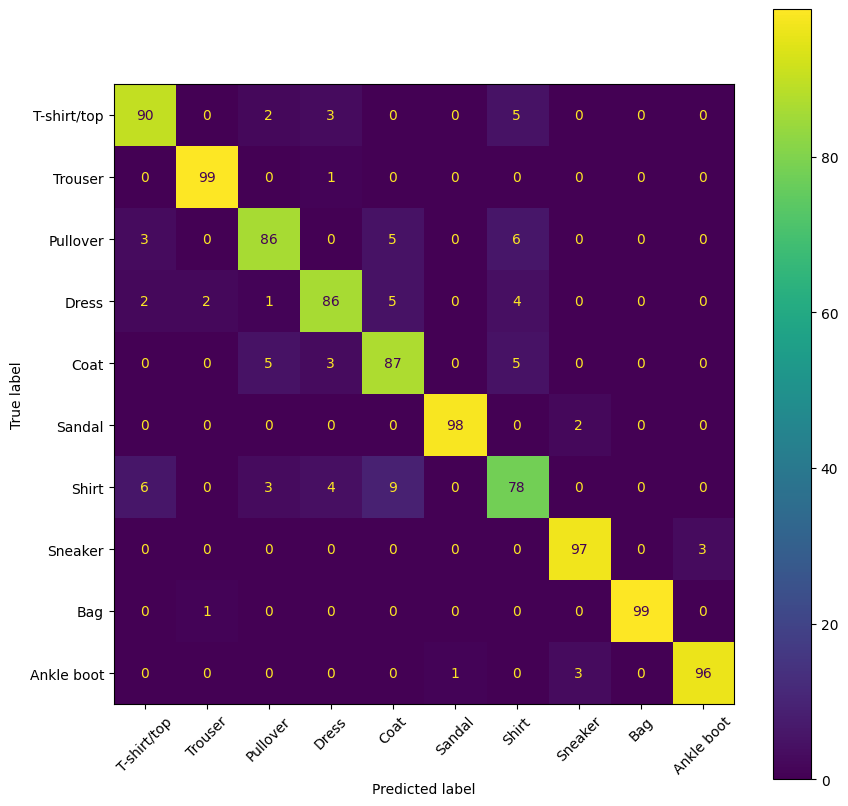

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()